In [2]:
# Install libraries
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import pandas as pd
import numpy as np
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Path ke credential
CREDENTIAL_PATH = Path(
    "C:/Users/USER/Documents/project/Internpro/colab-service-account.json"
)

# Scope akses
scope = [
    "https://spreadsheets.google.com/feeds",
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
]

# Load credential
creds = ServiceAccountCredentials.from_json_keyfile_name(
    CREDENTIAL_PATH,
    scope
)

client = gspread.authorize(creds)

In [4]:
def read_sheet(spreadsheet_id, gid=None, sheet_name=None):
    """
    Baca Google Sheet menjadi DataFrame
    """
    sh = client.open_by_key(spreadsheet_id)

    if sheet_name:
        ws = sh.worksheet(sheet_name)
    elif gid:
        ws = sh.get_worksheet_by_id(int(gid))
    else:
        ws = sh.sheet1

    data = ws.get_all_records()
    return pd.DataFrame(data)

In [5]:
sheet2_id = "18fJ2U96koMRctfbhybT1HsT2D95wgafLQMzlb-AwTvE"
df_sheet2 = read_sheet(sheet2_id)
print("Sheet 2:")
df_sheet2.head()

Sheet 2:


,Sumber Sheet,Tanggal Gabungan,Month,Product,Kategori,Hari,Bulan,Tahun,Batch,Umur,...,Channel,Mengapa memilih Dibimbing,Pernah/Tidak memiliki pengalaman di bidang yang diambil,Apakah memiliki skill bahasa inggris,Penyaluran Kerja,Blog dibimbing,Community,Pernah ikut acara dibimbing/tidak,Catatan,Pengembalian Kontrak
0,DS,2/Jan/2024,Jan 2024,Data Science,JCJC+,2,Jan,2024,26,33,...,Instagram,"Job Connector dan kualitas dari Dibimbing, ser...","Job Connector dan kualitas dari Dibimbing, ser...",,Tertarik,,-,Tidak,,-
1,DE,2/Jan/2024,Jan 2024,Data Engineering,CAJC,2,Jan,2024,4,24,...,Instagram,"Karena harga affordable, waktunya tidak mengga...","Karena harga affordable, waktunya tidak mengga...",,,Tidak,,Tidak,Pernah mengikuti Bootcamp di Altera Academy un...,
2,PMPM,2/Jan/2024,Jan 2024,Product Management,JCJC+,2,Jan,2024,9,27,...,Google Ads,Kurikulum di Dibimbing paling sesuai dan harga...,Kurikulum di Dibimbing paling sesuai dan harga...,,tertarik,Tidak,Tidak,Tidak,,
3,DM,2/Jan/2024,Jan 2024,Digital Marketing,JCJC+,2,Jan,2024,23,29,...,Instagram,"Dari sisi silabus materinya lengkap, harganya ...","Dari sisi silabus materinya lengkap, harganya ...",,Tertarik,Tidak,Tidak,Pernah (mentortalks tahun 2023),-,-
4,UIUX,3/Jan/2024,Jan 2024,UI/UX,JCJC+,3,Jan,2024,24,24,...,Refferal,di Linkedin dan di CV diperbarui sehingga dapa...,di Linkedin dan di CV diperbarui sehingga dapa...,,Tertarik,,Tidak,Tidak,Pernah mengikuti Intern di rakaming dan bekerj...,


# Data Inspections

In [6]:
df_sheet2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 40 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Sumber Sheet                                             3071 non-null   object
 1   Tanggal Gabungan                                         3071 non-null   object
 2   Month                                                    3071 non-null   object
 3   Product                                                  3071 non-null   object
 4   Kategori                                                 3071 non-null   object
 5   Hari                                                     3071 non-null   int64 
 6   Bulan                                                    3071 non-null   object
 7   Tahun                                                    3071 non-null   int64 
 8   Batch                                 

In [7]:
df_sheet2.columns

Index(['Sumber Sheet', 'Tanggal Gabungan', 'Month', 'Product', 'Kategori',
       'Hari', 'Bulan', 'Tahun', 'Batch', 'Umur', 'Domisili', 'Kota',
       'Kota(Jabodetabek)', 'Provinsi', 'Negara', 'Background pendidikan',
       'Asal Sekolah', 'Level pendidikan', 'Jurusan pendidikan', 'Jurusan',
       'Jurusan S2 (jika ada)', 'Kesibukan sekarang apa', 'Kategori Kesibukan',
       'Level Pekerjaan', 'Kategori Pekerjaan',
       'Waktu terakhir bekerja (kalau lagi nggak kerja/intern)',
       'Kegiatan yang dilakukan waktu luang/Hobi',
       'Alasan mengambil kategori Bootcamp', 'Motivasi mengikuti bootcamp',
       'Dengar Dibimbing darimana', 'Channel', 'Mengapa memilih Dibimbing',
       'Pernah/Tidak memiliki pengalaman di bidang yang diambil',
       'Apakah memiliki skill bahasa inggris', 'Penyaluran Kerja',
       'Blog dibimbing', 'Community', 'Pernah ikut acara dibimbing/tidak',
       'Catatan', 'Pengembalian Kontrak'],
      dtype='object')

In [8]:
df_sheet2.describe()

,Hari,Tahun
count,3071.000000,3071.000000
mean,15.834582,2024.562683
std,8.736981,0.496136
min,1.000000,2024.000000
25%,8.000000,2024.000000
50%,16.000000,2025.000000
75%,23.000000,2025.000000
max,31.000000,2025.000000


In [9]:
for col in df_sheet2.columns:
    print(f"======= {col} =======")
    display(df_sheet2[col].nunique())
    print()

======= Sumber Sheet =======


27


======= Tanggal Gabungan =======


570


======= Month =======


...

87


======= Catatan =======


2267


======= Pengembalian Kontrak =======


2

In [10]:
for col in df_sheet2.columns:
    print(f"======= {col} =======")
    display(df_sheet2[col].value_counts())
    print()

======= Sumber Sheet =======


Sumber Sheet
DS            656
HR            351
DM            312
BI            252
UIUX          208
PMPM          191
ML            172
FE            162
DE            146
CS            123
BE             76
BD             68
FA             56
SCM            42
ESG_SM         40
QA             36
DABI           35
DSML           31
FWD            23
DS_Offline     20
MA             18
PR             16
IB             15
EP             13
DM_Offline      6
AU              2
HSE             1
Name: count, dtype: int64


======= Tanggal Gabungan =======


Tanggal Gabungan
29/Jun/2025    16
26/Jun/2025    16
6/Agu/2024     12
30/Jul/2024    12
28/Jun/2025    10
               ..
2/Okt/2024      1
7/Agu/2024      1
5/Sep/2024      1
29/Jun/2024     1
12/Jan/2024     1
Name: count, Length: 570, dtype: int64


======= Month =======


...

Pernah ikut acara dibimbing/tidak
Tidak                                                                            2786
Ya                                                                                189
Tidak                                                                               7
Iya                                                                                 4
                                                                                    3
                                                                                 ... 
Ya (Mengikuti Digital Marketing Series 28 selama kurang lebih 1 minggu)             1
Ya (Pernah mengikuti DSF UI/UX  selama 2 hari dengan mentor Kak Fadel)              1
\nTidak                                                                             1
Ya (pernah mengikuti DSF untuk topik Project Management pada tahun ini)             1
Ya (pernah mengikuti DSF dengan topik Human Resource kurang lebih tahun lalu)       1
Name: count, Length:


======= Catatan =======


Catatan
-                                                                                                                                                        384
                                                                                                                                                          70
Instagram Ads (tahu Dibimbing dari ads instagram lalu dilihat-lihat tertarik dan register)                                                                32
Instagram Ads (tahu Dibimbing dari ads instagram tiba-tiba muncul lalu dia lihat-lihat tertarik dan register)                                             31
Instagram Ads (tahu Dibimbing dari ads instagram tiba-tiba muncul lalu dilihat-lihat tertarik dan register)                                               31
                                                                                                                                                        ... 
Instagram search sendiri (tahu Dibimbing dari sear


======= Pengembalian Kontrak =======


Pengembalian Kontrak
-    2351
      720
Name: count, dtype: int64

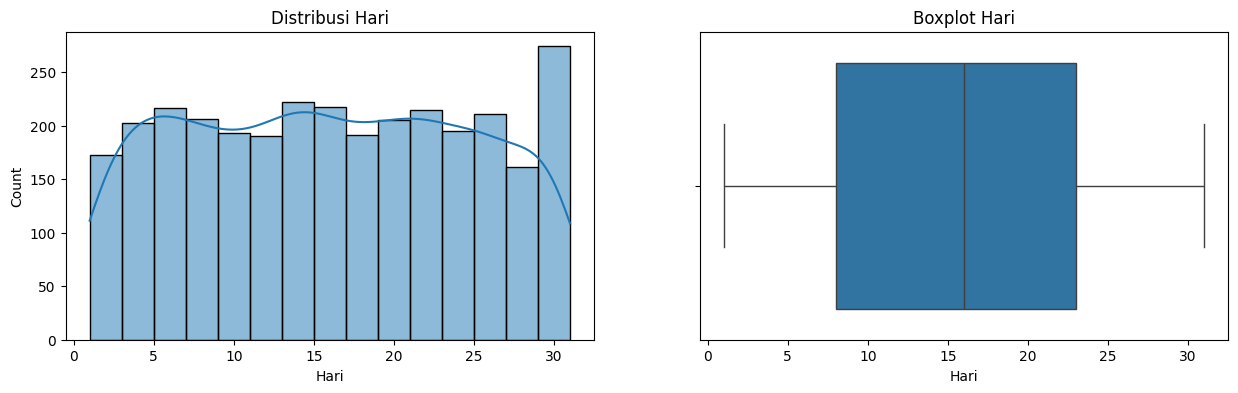

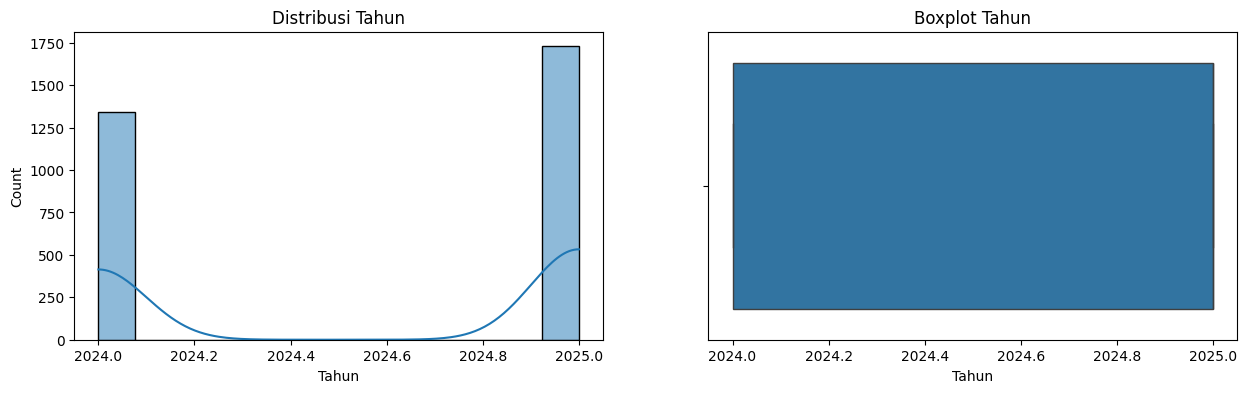

In [11]:
num = df_sheet2.select_dtypes(include=[np.number]).columns

for col in num:
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    sns.histplot(df_sheet2[col], kde=True)
    plt.title(f"Distribusi {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df_sheet2[col])
    plt.title(f"Boxplot {col}")

    plt.show()

## Data Understanding

The dataset consists of 3,071 rows and 40 columns, representing participant and sales-related information from multiple sources. The dataset spans January 2024 to October 2025 and covers both online and offline programs. Each row corresponds to a single participant or transaction record, includes:
1.	Source & Program Information
    - Sumber Sheet: Origin of the data source, representing different bootcamp programs (e.g., Data Science, Digital Marketing, HR, UI/UX).
    - Product: Bootcamp product name (e.g., Data Science, Product Management, Cyber Security).
    - Kategori: Program type classification (e.g., JCJC+, CAJC).
2. Temporal Information
    - Tanggal Gabungan: Enrollment or registration date (string format).
    - Month, Bulan, Hari, Tahun: Derived date components.

    -> The presence of multiple time-related columns introduces redundancy and inconsistency risk, as the same date information is represented in different formats and languages.
3. Demographic & Geographic Attributes
    - Umur: Participant age (numeric and text-mixed).
    - Domisili, Kota, Provinsi, Negara
    - Kota (Jabodetabek): Geographic grouping indicator.
4. Education Background
    - Background pendidikan
    - Asal Sekolah
    - Level pendidikan
    - Jurusan pendidikan
    - Jurusan
    - Jurusan S2 (jika ada)
5. Employment & Career Status
    - Kesibukan sekarang apa
    - Kategori Kesibukan
    - Level Pekerjaan
    - Kategori Pekerjaan
    - Waktu terakhir bekerja
6. Marketing & Behavioral Information
    - Dengar Dibimbing darimana
    - Channel
    - Mengapa memilih Dibimbing
    - Alasan mengambil kategori Bootcamp
    - Motivasi mengikuti bootcamp
7. Outcome & Engagement Indicators
    - Pernah/Tidak memiliki pengalaman di bidang yang diambil
    - Apakah memiliki skill bahasa inggris
    - Penyaluran Kerja
    - Blog dibimbing
    - Community
    - Pernah ikut acara dibimbing/tidak
    - Pengembalian Kontrak
- Several columns are stored as object data types despite representing structured or ordinal information, such as:
    - Tanggal Gabungan (date)
    - Umur (age group)
    - Time-related fields (Month, Bulan)
    
    However, the time data overlaps with the date column, so it's reasonable to drop it.
- The dataset is indicated to have no missing values, as all columns contain 3,071 non-null entries. Howevery, after checking the data through google sheets, there are data that contains empty strings, hyphens (-), or whitespace. The columns are Kategori, Blog dibimbing, Community, Jurusan S2, 
- There are also several columns contains inconsistent value that need to be normalized and cleaning. The columns are Dengar Dibimbing darimana, Channel, Penyaluran Kerja, Blog dibimbing, Community, Pernah ikut acara dibimbing/tidak, Kategori Kesibukan, Level Pekerjaan, Level pendidikan.
- There is columns that contain mixed data types (numeric and non-numeric value), such as umur. 
- There are several columns with hundreds to thousands of unique values, in other words is "high cardinality free text", 

# Data Preparation

In [12]:
df_sheet2.columns

Index(['Sumber Sheet', 'Tanggal Gabungan', 'Month', 'Product', 'Kategori',
       'Hari', 'Bulan', 'Tahun', 'Batch', 'Umur', 'Domisili', 'Kota',
       'Kota(Jabodetabek)', 'Provinsi', 'Negara', 'Background pendidikan',
       'Asal Sekolah', 'Level pendidikan', 'Jurusan pendidikan', 'Jurusan',
       'Jurusan S2 (jika ada)', 'Kesibukan sekarang apa', 'Kategori Kesibukan',
       'Level Pekerjaan', 'Kategori Pekerjaan',
       'Waktu terakhir bekerja (kalau lagi nggak kerja/intern)',
       'Kegiatan yang dilakukan waktu luang/Hobi',
       'Alasan mengambil kategori Bootcamp', 'Motivasi mengikuti bootcamp',
       'Dengar Dibimbing darimana', 'Channel', 'Mengapa memilih Dibimbing',
       'Pernah/Tidak memiliki pengalaman di bidang yang diambil',
       'Apakah memiliki skill bahasa inggris', 'Penyaluran Kerja',
       'Blog dibimbing', 'Community', 'Pernah ikut acara dibimbing/tidak',
       'Catatan', 'Pengembalian Kontrak'],
      dtype='object')

In [13]:
df_sheet2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 40 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Sumber Sheet                                             3071 non-null   object
 1   Tanggal Gabungan                                         3071 non-null   object
 2   Month                                                    3071 non-null   object
 3   Product                                                  3071 non-null   object
 4   Kategori                                                 3071 non-null   object
 5   Hari                                                     3071 non-null   int64 
 6   Bulan                                                    3071 non-null   object
 7   Tahun                                                    3071 non-null   int64 
 8   Batch                                 

In [14]:
# Standaridze Column Names
df_sheet2.columns = (
    df_sheet2.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[()/]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

# Drop Columns
df_sheet2 = df_sheet2.drop(columns=["hari", "bulan", "month", "tahun"], errors="ignore")

df_sheet2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 36 columns):
 #   Column                                                  Non-Null Count  Dtype 
---  ------                                                  --------------  ----- 
 0   sumber_sheet                                            3071 non-null   object
 1   tanggal_gabungan                                        3071 non-null   object
 2   product                                                 3071 non-null   object
 3   kategori                                                3071 non-null   object
 4   batch                                                   3071 non-null   object
 5   umur                                                    3071 non-null   object
 6   domisili                                                3071 non-null   object
 7   kota                                                    3071 non-null   object
 8   kotajabodetabek                                 

In [15]:
col = ["batch", "umur"]

for c in col:
    print(f"======= {c} =======")
    display(df_sheet2[c].value_counts())
    print()

======= batch =======


batch
1      290
2      161
3      123
7      115
4       97
      ... 
27B      1
         1
42+      1
6+       1
42       1
Name: count, Length: 92, dtype: int64


======= umur =======


umur
24                  403
23                  387
25                  344
22                  342
26                  257
27                  222
21                  166
28                  151
29                  133
30                  120
20                   85
32                   70
31                   68
33                   50
19                   42
34                   38
18                   33
36                   20
35                   17
38                   11
37                   11
44                    8
17                    8
40                    7
16                    7
39                    7
42                    6
50                    5
45                    5
48                    5
43                    4
41                    4
47                    3
15                    3
49                    2
46                    2
29 tahun              2
25 tahun              2
24 Tahun              2
                      2
55                    2
53         

In [16]:
# Standarize Format Columns
df_sheet2["batch"] = (
    df_sheet2["batch"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
)

df_sheet2["umur"] = (
    df_sheet2["umur"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

for c in col:
    print(f"======= {c} =======")
    display(df_sheet2[c].value_counts())
    print()
    print(df_sheet2[c].dtype)

======= batch =======


batch
1.0     297
2.0     174
3.0     134
27.0    132
32.0    116
7.0     115
28.0    107
33.0    103
29.0    101
4.0      99
26.0     97
6.0      95
5.0      95
8.0      92
30.0     91
12.0     83
10.0     81
31.0     76
11.0     75
25.0     68
13.0     63
19.0     58
14.0     57
9.0      54
24.0     53
15.0     50
17.0     48
37.0     46
36.0     45
18.0     44
34.0     40
16.0     39
39.0     37
23.0     36
35.0     34
38.0     33
40.0     29
20.0     29
22.0     23
21.0     17
42.0      2
41.0      2
Name: count, dtype: int64


float64
======= umur =======


umur
24.0    406
23.0    388
25.0    346
22.0    344
26.0    259
27.0    222
21.0    167
28.0    153
29.0    135
30.0    120
20.0     85
32.0     70
31.0     68
33.0     50
19.0     42
34.0     38
18.0     33
36.0     20
35.0     17
37.0     11
38.0     11
17.0      8
39.0      8
44.0      8
40.0      7
16.0      7
42.0      6
45.0      5
50.0      5
48.0      5
41.0      4
43.0      4
47.0      3
15.0      3
46.0      2
55.0      2
49.0      2
51.0      1
53.0      1
54.0      1
52.0      1
Name: count, dtype: int64


float64


In [17]:
cat_cols = df_sheet2.select_dtypes(include=["object"]).columns

for col in cat_cols:
    count = (
        df_sheet2[col]
        .astype(str)
        .str.strip()
        .isin(["", "-"])
        .sum()
    )
    print(f"{col}: {count}")


sumber_sheet: 0
tanggal_gabungan: 0
product: 1
kategori: 1
domisili: 2
kota: 77
kotajabodetabek: 77
provinsi: 6
negara: 6
background_pendidikan: 2
asal_sekolah: 35
level_pendidikan: 9
jurusan_pendidikan: 557
jurusan: 575
jurusan_s2_jika_ada: 2823
kesibukan_sekarang_apa: 3
kategori_kesibukan: 3
level_pekerjaan: 10
kategori_pekerjaan: 10
waktu_terakhir_bekerja_kalau_lagi_nggak_kerjaintern: 2220
kegiatan_yang_dilakukan_waktu_luanghobi: 1558
alasan_mengambil_kategori_bootcamp: 545
motivasi_mengikuti_bootcamp: 212
dengar_dibimbing_darimana: 18
channel: 18
mengapa_memilih_dibimbing: 24
pernahtidak_memiliki_pengalaman_di_bidang_yang_diambil: 13
apakah_memiliki_skill_bahasa_inggris: 724
penyaluran_kerja: 169
blog_dibimbing: 1410
community: 573
pernah_ikut_acara_dibimbingtidak: 4
catatan: 454
pengembalian_kontrak: 3071


In [18]:
# Standarize White Spaces and Hypens to NaN
df_sheet2[cat_cols] = (df_sheet2[cat_cols].astype(str).apply(lambda s: s.str.strip()).replace(["", "-"], np.nan))
df_sheet2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 36 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   sumber_sheet                                            3071 non-null   object 
 1   tanggal_gabungan                                        3071 non-null   object 
 2   product                                                 3070 non-null   object 
 3   kategori                                                3070 non-null   object 
 4   batch                                                   3070 non-null   float64
 5   umur                                                    3068 non-null   float64
 6   domisili                                                3069 non-null   object 
 7   kota                                                    2994 non-null   object 
 8   kotajabodetabek                       

C:\Users\USER\AppData\Local\Temp\ipykernel_1468\4210913866.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sheet2[cat_cols] = (df_sheet2[cat_cols].astype(str).apply(lambda s: s.str.strip()).replace(["", "-"], np.nan))


In [19]:
print(df_sheet2.isna().sum())

# Presentase Missing Values
missing_percentage = ((df_sheet2.isna().sum() / len(df_sheet2)) * 100).round(2)
missing_percentage = missing_percentage[missing_percentage > 0]
missing_percentage

sumber_sheet                                                 0
tanggal_gabungan                                             0
product                                                      1
kategori                                                     1
batch                                                        1
umur                                                         3
domisili                                                     2
kota                                                        77
kotajabodetabek                                             77
provinsi                                                     6
negara                                                       6
background_pendidikan                                        2
asal_sekolah                                                35
level_pendidikan                                             9
jurusan_pendidikan                                         557
jurusan                                                

product                                                     0.03
kategori                                                    0.03
batch                                                       0.03
umur                                                        0.10
domisili                                                    0.07
kota                                                        2.51
kotajabodetabek                                             2.51
provinsi                                                    0.20
negara                                                      0.20
background_pendidikan                                       0.07
asal_sekolah                                                1.14
level_pendidikan                                            0.29
jurusan_pendidikan                                         18.14
jurusan                                                    18.72
jurusan_s2_jika_ada                                        91.92
kesibukan_sekarang_apa   

In [20]:
df_sheet2.head()

,sumber_sheet,tanggal_gabungan,product,kategori,batch,umur,domisili,kota,kotajabodetabek,provinsi,...,channel,mengapa_memilih_dibimbing,pernahtidak_memiliki_pengalaman_di_bidang_yang_diambil,apakah_memiliki_skill_bahasa_inggris,penyaluran_kerja,blog_dibimbing,community,pernah_ikut_acara_dibimbingtidak,catatan,pengembalian_kontrak
0,DS,2/Jan/2024,Data Science,JCJC+,26.0,33.0,Yogyakarta,Yogyakarta,Yogyakarta,Yogyakarta,...,Instagram,"Job Connector dan kualitas dari Dibimbing, ser...","Job Connector dan kualitas dari Dibimbing, ser...",NaN,Tertarik,NaN,NaN,Tidak,NaN,NaN
1,DE,2/Jan/2024,Data Engineering,CAJC,4.0,24.0,Jakarta Barat,Jakarta,Jabodetabek,DKI Jakarta,...,Instagram,"Karena harga affordable, waktunya tidak mengga...","Karena harga affordable, waktunya tidak mengga...",NaN,NaN,Tidak,NaN,Tidak,Pernah mengikuti Bootcamp di Altera Academy un...,NaN
2,PMPM,2/Jan/2024,Product Management,JCJC+,9.0,27.0,Jakarta Selatan,Jakarta,Jabodetabek,DKI Jakarta,...,Google Ads,Kurikulum di Dibimbing paling sesuai dan harga...,Kurikulum di Dibimbing paling sesuai dan harga...,NaN,tertarik,Tidak,Tidak,Tidak,NaN,NaN
3,DM,2/Jan/2024,Digital Marketing,JCJC+,23.0,29.0,Balikpapan,Bali,Bali,Bali,...,Instagram,"Dari sisi silabus materinya lengkap, harganya ...","Dari sisi silabus materinya lengkap, harganya ...",NaN,Tertarik,Tidak,Tidak,Pernah (mentortalks tahun 2023),NaN,NaN
4,UIUX,3/Jan/2024,UI/UX,JCJC+,24.0,24.0,Boyolali,Boyolali,Boyolali,Jawa Tengah,...,Refferal,di Linkedin dan di CV diperbarui sehingga dapa...,di Linkedin dan di CV diperbarui sehingga dapa...,NaN,Tertarik,NaN,Tidak,Tidak,Pernah mengikuti Intern di rakaming dan bekerj...,NaN


In [25]:
# Standarize Format
df_sheet2["domisili_clean"] = (
    df_sheet2["domisili"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({"-": np.nan, "": np.nan})
)

# Mapping Domisili
jabodetabek_keywords = [
    "jakarta", "bogor", "depok", "tangerang", "bekasi"
]
java_provinces = [
    "jawa barat", "jawa tengah", "jawa timur",
    "banten", "dki jakarta", "di yogyakarta", "yogyakarta"
]

# Function to map domisili
def map_region(text):
    if pd.isna(text):
        return "unknown"
    
    # Jabodetabek
    if any(k in text for k in jabodetabek_keywords):
        return "jabodetabek"
    
    # Java (non Jabodetabek)
    if any(p in text for p in java_provinces):
        return "java_non_jabodetabek"
    
    return "outside_java"

# Apply mapping
df_sheet2["region"] = df_sheet2["domisili_clean"].apply(map_region)
df_sheet2["region"].value_counts()

region
jabodetabek             1505
outside_java            1053
java_non_jabodetabek     513
Name: count, dtype: int64

In [30]:
eda_cols = ['tanggal_gabungan', 'product', 'kategori', 'umur', 'domisili_eda_top10',
       'domisili_clean', 'region', 'background_pendidikan', 'jurusan', 
       'channel', 'kategori_kesibukan', 'kategori_pekerjaan', 'pernah_ikut_acara_dibimbingtidak'
       ]

eda = df_sheet2[eda_cols]
eda

,tanggal_gabungan,product,kategori,umur,domisili_eda_top10,domisili_clean,region,background_pendidikan,jurusan,channel,kategori_kesibukan,kategori_pekerjaan,pernah_ikut_acara_dibimbingtidak
0,2/Jan/2024,Data Science,JCJC+,33.0,other,yogyakarta,java_non_jabodetabek,Sekolah Tinggi Ilmu Ekonomi Papua (S1) dan UPN...,Akuntansi,Instagram,Job seeker,Job Seeker,Tidak
1,2/Jan/2024,Data Engineering,CAJC,24.0,Jakarta Barat,jakarta barat,jabodetabek,Universitas Bung Karno,Sistem Informasi,Instagram,Pekerja,PNS,Tidak
2,2/Jan/2024,Product Management,JCJC+,27.0,Jakarta Selatan,jakarta selatan,jabodetabek,Universitas Negeri Sankt Peterburg (Rusia),Hubungan Internasional,Google Ads,Pekerja,Karyawan Swasta,Tidak
3,2/Jan/2024,Digital Marketing,JCJC+,29.0,other,balikpapan,outside_java,Universitas Telkom,NaN,Instagram,Pekerja,Karyawan (di anak perusahaan PLN yaitu PLN Nus...,Pernah (mentortalks tahun 2023)
4,3/Jan/2024,UI/UX,JCJC+,24.0,other,boyolali,outside_java,Universitas Amikom Yogyakarta,Sistem Informasi,Refferal,Pekerja,Freelance (Karadividia Yoyakarta sebagai Noteker),Tidak
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3066,1/Nov/2025,ESG & Sustainability,CAJC,24.0,Jakarta,jakarta,jabodetabek,Universitas Brawijaya,NaN,Instagram,Job seeker,Job Seeker,Tidak
3067,2/Nov/2025,ESG & Sustainability,CAJC,23.0,other,"jakarta selatan, dki jakarta",jabodetabek,Institut Teknologi Bandung,NaN,Instagram,Pekerja,Karyawan Swasta,Tidak
3068,2/Nov/2025,Data Science & Machine Learning,CAJC,26.0,Jakarta Timur,jakarta timur,jabodetabek,Institut Teknologi Dirgantara Adisutjipto,Teknik,Organic,Pekerja,Karyawan Swasta,Tidak
3069,2/Nov/2025,Data Analyst & Business Intelligence,JCJC+,22.0,other,"jakarta timur, dki jakarta",jabodetabek,Institut Teknologi Sepuluh Nopember,NaN,TikTok Ads,Job seeker,Job Seeker,Tidak


In [31]:
for c in eda_cols:
    print(f"======= {c} =======")
    display(eda[c].value_counts())
    print()

======= tanggal_gabungan =======


tanggal_gabungan
29/Jun/2025    16
26/Jun/2025    16
6/Agu/2024     12
30/Jul/2024    12
28/Jun/2025    10
               ..
2/Okt/2024      1
7/Agu/2024      1
5/Sep/2024      1
29/Jun/2024     1
12/Jan/2024     1
Name: count, Length: 570, dtype: int64


======= product =======


product
Data Science                            656
Human Resource                          351
Digital Marketing                       312
Business Intelligence                   252
UI/UX                                   208
Product Management                      191
AI Machine Learning                     172
Web Development (FE)                    162
Data Engineering                        146
Cyber Security                          123
Back End Golang                          76
Business Development                     68
Finance & Accounting                     56
Supply Chain Management                  42
ESG & Sustainability                     40
Quality Assurance                        36
Data Analyst & Business Intelligence     35
Data Science & Machine Learning          31
Fullstack Web-Dev                        23
Data Science (Offline)                   20
Mobile App                               18
Public Relation                          16
Investment Banking      


======= kategori =======


...

kategori_kesibukan
Pekerja             1474
Job seeker           940
Mahasiswa            355
Fresh Graduate       123
Usaha                 76
Other                 44
Ibu Rumah Tangga      37
Siswa SMA/SMK         19
Name: count, dtype: int64


======= kategori_pekerjaan =======


kategori_pekerjaan
Karyawan Swasta           986
Job Seeker                928
Mahasiswa                 403
Freelance                 147
Karyawan                  144
                         ... 
Pemerintahan / Non-PNS      1
Honorer Pemerintah          1
Tenaga Kependidikan         1
Paruh Waktu                 1
Honorer/Outsourcing         1
Name: count, Length: 120, dtype: int64


======= pernah_ikut_acara_dibimbingtidak =======


pernah_ikut_acara_dibimbingtidak
Tidak                                                                            2794
Ya                                                                                189
Iya                                                                                 4
Pernah (Alumni data Science)                                                        1
Pernah (UI UX di tahun 2023)                                                        1
                                                                                 ... 
Ya (Mengikuti Digital Marketing Series 28 selama kurang lebih 1 minggu)             1
Ya (pernah ikut bootcamp BI Batch 3 dan saat ini menjadi alumni)                    1
Ya (Pernah mengikuti DSF UI/UX  selama 2 hari dengan mentor Kak Fadel)              1
Ya (pernah mengikuti DSF untuk topik Project Management pada tahun ini)             1
Ya (pernah mengikuti DSF dengan topik Human Resource kurang lebih tahun lalu)       1
Name: count, Length: 

# Problem Statement

- Business Context: (company profile and stakeholder target)

- Business Problem: (problem posibilities)

- Business Objectives: (expected output)

- Business Vaulue: (what did u offer with this project)


# Exploratory Data Analysis (EDA)

# Data Preprocessing before Modeling

## Encoding

## Scaling

# Modeling

# Final Evaluation

# Business Impact